# WDR91 — Train XGBoost + Tanimoto Similarity Ensemble

**Self-contained notebook.** Trains XGBoost on the DEL screen, then ranks Step 2 compounds by combining two complementary scores:
1. **XGBoost score** — learned from 375k DEL screen compounds (fingerprint-based)
2. **Tanimoto similarity score** — structural similarity to 177 known WDR91 active molecules

**Why ensemble?** XGBoost learned from DEL chemistry patterns. The known actives capture drug-like WDR91 binder scaffolds. Together they cover both DEL-derived and drug-like binding signals.

---
**Before running, upload to Google Drive:**
- `WDR91.parquet` → `My Drive/CS502/data/WDR91.parquet`
- `Step2_TestData_Target2035.parquet` → `My Drive/CS502/data/Step2_TestData_Target2035.parquet`
- `known_active_molecules.csv` → `My Drive/CS502/data/known_active_molecules.csv`

In [1]:
!pip install xgboost pyarrow tqdm seaborn rdkit -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 70.0 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

TRAIN_PATH   = '/content/drive/MyDrive/CS502/data/WDR91.parquet'
STEP2_PATH   = '/content/drive/MyDrive/CS502/data/Step2_TestData_Target2035.parquet'
ACTIVES_PATH = '/content/drive/MyDrive/CS502/data/known_active_molecules.csv'
MODEL_PATH   = '/content/drive/MyDrive/CS502/models/xgb_multifp.json'
OUTPUT_PATH  = '/content/drive/MyDrive/CS502/outputs/predictions_ensemble.csv'

Mounted at /content/drive


In [3]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow.parquet as pq
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, balanced_accuracy_score, recall_score
from pathlib import Path
from tqdm import tqdm
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs

%matplotlib inline
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

Path('/content/drive/MyDrive/CS502/models').mkdir(parents=True, exist_ok=True)
Path('/content/drive/MyDrive/CS502/outputs').mkdir(parents=True, exist_ok=True)

## Helper Functions

In [4]:
FP_DIMS = {'ECFP6': 2048, 'MACCS': 167, 'RDK': 2048}
FP_NAMES = ['ECFP6', 'MACCS', 'RDK']
SCALAR_COLS = ['COMPOUND_ID', 'LIBRARY_ID', 'BB1_ID', 'BB2_ID', 'BB3_ID',
               'TARGET_VALUE', 'LABEL', 'MW', 'ALOGP']


def sparse_indices_to_matrix(index_lists, n_bits):
    """Training data format: each value is an ON-bit index (list<int32>)."""
    rows, cols = [], []
    for i, bits in enumerate(index_lists):
        for b in bits:
            if b < n_bits:
                rows.append(i)
                cols.append(b)
    data = np.ones(len(rows), dtype=np.float32)
    return sp.csr_matrix((data, (rows, cols)), shape=(len(index_lists), n_bits))


def dense_string_to_matrix(dense_strings, n_bits):
    """Step 2 format: full comma-separated vector (e.g. '0,1,0,1,...')."""
    rows, cols = [], []
    for i, s in enumerate(dense_strings):
        arr = np.array(s.split(','), dtype=np.int32)
        on_bits = np.where(arr > 0)[0]
        rows.extend([i] * len(on_bits))
        cols.extend(on_bits.tolist())
    data = np.ones(len(rows), dtype=np.float32)
    return sp.csr_matrix((data, (rows, cols)), shape=(len(dense_strings), n_bits))


def load_train_fingerprints(path, fp_names=FP_NAMES, batch_size=50_000):
    """Load WDR91 training data (sparse index format)."""
    pf = pq.ParquetFile(path)
    scalar_frames, fp_batches = [], {fp: [] for fp in fp_names}
    for batch in tqdm(pf.iter_batches(batch_size=batch_size, columns=SCALAR_COLS + fp_names),
                      desc='Loading training data'):
        df = batch.to_pandas()
        scalar_frames.append(df[SCALAR_COLS])
        for fp in fp_names:
            fp_batches[fp].append(sparse_indices_to_matrix(df[fp].tolist(), FP_DIMS[fp]))
    X = sp.hstack([sp.vstack(fp_batches[fp], format='csr') for fp in fp_names], format='csr')
    df_meta = pd.concat(scalar_frames, ignore_index=True)
    print(f'Training data: {X.shape[0]:,} compounds, {X.shape[1]} features')
    return X, df_meta


def load_step2_fingerprints(path, fp_names=FP_NAMES, batch_size=20_000):
    """Load Step 2 data (dense string format)."""
    pf = pq.ParquetFile(path)
    id_lists, smiles_lists, fp_batches = [], [], {fp: [] for fp in fp_names}
    for batch in tqdm(pf.iter_batches(batch_size=batch_size, columns=['RandomID', 'SMILES'] + fp_names),
                      desc='Loading Step 2'):
        df = batch.to_pandas()
        id_lists.append(df['RandomID'])
        smiles_lists.append(df['SMILES'])
        for fp in fp_names:
            fp_batches[fp].append(dense_string_to_matrix(df[fp].tolist(), FP_DIMS[fp]))
    X = sp.hstack([sp.vstack(fp_batches[fp], format='csr') for fp in fp_names], format='csr')
    print(f'Step 2 data: {X.shape[0]:,} compounds, {X.shape[1]} features')
    return X, pd.concat(id_lists, ignore_index=True), pd.concat(smiles_lists, ignore_index=True)


def enrichment_factor(y_true, y_score, frac=0.01):
    n = len(y_true)
    n_top = max(1, int(n * frac))
    top_idx = np.argsort(y_score)[::-1][:n_top]
    hits_in_top = y_true[top_idx].sum()
    total_hits = y_true.sum()
    return 0.0 if total_hits == 0 else (hits_in_top / n_top) / (total_hits / n)


def smiles_to_morgan(smiles_list, radius=3, n_bits=2048):
    fps, valid_idx = [], []
    for i, smi in enumerate(smiles_list):
        mol = Chem.MolFromSmiles(smi)
        if mol is not None:
            fps.append(AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=n_bits))
            valid_idx.append(i)
    return fps, valid_idx


def max_tanimoto_similarity(query_fps, ref_fps, batch_size=5000):
    scores = np.zeros(len(query_fps))
    for start in tqdm(range(0, len(query_fps), batch_size), desc='Tanimoto similarity'):
        for j, qfp in enumerate(query_fps[start:start + batch_size]):
            scores[start + j] = max(DataStructs.BulkTanimotoSimilarity(qfp, ref_fps))
    return scores


def rank_normalize(scores):
    ranks = scores.argsort().argsort()
    return ranks / (len(ranks) - 1)

## 1. Load Training Data

In [5]:
X_train, df_meta = load_train_fingerprints(TRAIN_PATH)
y = df_meta['LABEL'].values
print(f'Hits: {y.sum():,} / {len(y):,} ({100*y.mean():.2f}%)')

Loading training data: 8it [10:29, 78.65s/it]

Training data: 375,595 compounds, 4263 features
Hits: 28,778 / 375,595 (7.66%)


## 2. Train XGBoost (80/20 Split)

In [6]:
X_tr, X_te, y_tr, y_te = train_test_split(X_train, y, test_size=0.2, stratify=y, random_state=42)
X_tr, X_te = X_tr.astype(np.float32), X_te.astype(np.float32)

SPW = (y_tr == 0).sum() / (y_tr == 1).sum()
print(f'Train: {X_tr.shape[0]:,}  Test: {X_te.shape[0]:,}  scale_pos_weight: {SPW:.2f}')

model = xgb.XGBClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, scale_pos_weight=SPW,
    eval_metric='aucpr', random_state=42, n_jobs=-1, verbosity=0,
)
model.fit(X_tr, y_tr)
print('Training complete.')

Train: 300,476  Test: 75,119  scale_pos_weight: 12.05
Training complete.


## 3. Evaluate on Test Set

In [7]:
y_prob_te = model.predict_proba(X_te)[:, 1]
y_pred_te = (y_prob_te >= 0.5).astype(int)

print('=== Test Set Results ===')
print(f'  ROC-AUC  : {roc_auc_score(y_te, y_prob_te):.4f}')
print(f'  PR-AUC   : {average_precision_score(y_te, y_prob_te):.4f}')
print(f'  Bal. Acc.: {balanced_accuracy_score(y_te, y_pred_te):.4f}')
print(f'  Recall   : {recall_score(y_te, y_pred_te):.4f}')
print(f'  EF@1%    : {enrichment_factor(y_te, y_prob_te, 0.01):.4f}')
print(f'  EF@5%    : {enrichment_factor(y_te, y_prob_te, 0.05):.4f}')

=== Test Set Results ===
  ROC-AUC  : 0.7665
  PR-AUC   : 0.2932
  Bal. Acc.: 0.6900
  Recall   : 0.6704
  EF@1%    : 8.9494
  EF@5%    : 4.8761


## 4. Retrain on Full Dataset & Save

In [8]:
SPW_full = (y == 0).sum() / (y == 1).sum()
final_model = xgb.XGBClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, scale_pos_weight=SPW_full,
    eval_metric='aucpr', random_state=42, n_jobs=-1, verbosity=0,
)
final_model.fit(X_train.astype(np.float32), y)
final_model.save_model(MODEL_PATH)
print(f'Final model saved to {MODEL_PATH}')

Final model saved to /content/drive/MyDrive/CS502/models/xgb_multifp.json


## 5. Load Step 2 Data

In [9]:
X_step2, compound_ids, smiles_series = load_step2_fingerprints(STEP2_PATH)

Loading Step 2: 17it [04:17, 15.16s/it]


Step 2 data: 339,258 compounds, 4263 features


## 6. XGBoost Predictions on Step 2

In [10]:
print('Predicting on Step 2...')
xgb_scores = final_model.predict_proba(X_step2.astype(np.float32))[:, 1]
print(f'Scores: min={xgb_scores.min():.4f}  max={xgb_scores.max():.4f}  mean={xgb_scores.mean():.4f}')

Predicting on Step 2...
Scores: min=0.0009  max=0.3205  mean=0.0167


## 7. Load Known Actives & Compute Tanimoto Similarity

177 confirmed WDR91 binders used as structural reference. For each Step 2 compound, the maximum Tanimoto similarity to any known active is computed.

In [11]:
actives_df = pd.read_csv(ACTIVES_PATH)
print(f'Known actives: {len(actives_df)}')

ref_fps, _ = smiles_to_morgan(actives_df['SMILES'].tolist())
print(f'Parsed {len(ref_fps)} / {len(actives_df)} reference SMILES')

print('\nConverting Step 2 SMILES to Morgan fingerprints...')
query_fps, query_valid_idx = smiles_to_morgan(smiles_series.tolist())
print(f'Parsed {len(query_fps):,} / {len(smiles_series):,} query SMILES')

tanimoto_scores = np.zeros(len(smiles_series))
raw_sims = max_tanimoto_similarity(query_fps, ref_fps)
for i, idx in enumerate(query_valid_idx):
    tanimoto_scores[idx] = raw_sims[i]

print(f'\nTanimoto: min={tanimoto_scores.min():.4f}  max={tanimoto_scores.max():.4f}  mean={tanimoto_scores.mean():.4f}')
print(f'Compounds with similarity > 0.5: {(tanimoto_scores > 0.5).sum():,}')
print(f'Compounds with similarity > 0.3: {(tanimoto_scores > 0.3).sum():,}')

Known actives: 177
Parsed 177 / 177 reference SMILES

Converting Step 2 SMILES to Morgan fingerprints...


Streaming output truncated to the last 5000 lines.
[23:07:48] DEPRECATION WARNING: please use MorganGenerator
[23:07:48] DEPRECATION WARNING: please use MorganGenerator
[23:07:48] DEPRECATION WARNING: please use MorganGenerator
[23:07:48] DEPRECATION WARNING: please use MorganGenerator
[23:07:48] DEPRECATION WARNING: please use MorganGenerator
[23:07:48] DEPRECATION WARNING: please use MorganGenerator
[23:07:48] DEPRECATION WARNING: please use MorganGenerator
[23:07:48] DEPRECATION WARNING: please use MorganGenerator
[23:07:48] DEPRECATION WARNING: please use MorganGenerator
[23:07:48] DEPRECATION WARNING: please use MorganGenerator
[23:07:48] DEPRECATION WARNING: please use MorganGenerator
[23:07:48] DEPRECATION WARNING: please use MorganGenerator
[23:07:48] DEPRECATION WARNING: please use MorganGenerator
[23:07:48] DEPRECATION WARNING: please use MorganGenerator
[23:07:48] DEPRECATION WARNING: please use MorganGenerator
[23:07:48] DEPRECATION WARNING: please use MorganGenerator
[23:0

Parsed 339,258 / 339,258 query SMILES


Tanimoto similarity: 100%|██████████| 68/68 [00:07<00:00,  8.74it/s]



Tanimoto: min=0.0841  max=1.0000  mean=0.1985
Compounds with similarity > 0.5: 664
Compounds with similarity > 0.3: 13,397


## 8. Ensemble: Rank-Normalize + Weighted Average

In [12]:
XGB_WEIGHT = 0.6  # XGBoost gets higher weight (trained on labeled DEL data)

xgb_norm      = rank_normalize(xgb_scores)
tanimoto_norm = rank_normalize(tanimoto_scores)
ensemble_scores = XGB_WEIGHT * xgb_norm + (1 - XGB_WEIGHT) * tanimoto_norm

results = pd.DataFrame({
    'RandomID':       compound_ids,
    'SMILES':         smiles_series,
    'xgb_score':      xgb_scores,
    'tanimoto_score': tanimoto_scores,
    'ensemble_score': ensemble_scores,
})
results = results.sort_values('ensemble_score', ascending=False).reset_index(drop=True)
results['rank'] = results.index + 1

corr = np.corrcoef(xgb_scores, tanimoto_scores)[0, 1]
print(f'Score correlation (XGBoost vs Tanimoto): {corr:.4f}')
print('(Low correlation = complementary signals)')
print(f'\nTop 10 by ensemble score:')
print(results[['rank','RandomID','xgb_score','tanimoto_score','ensemble_score']].head(10).to_string(index=False))

Score correlation (XGBoost vs Tanimoto): -0.0973
(Low correlation = complementary signals)

Top 10 by ensemble score:
 rank  RandomID  xgb_score  tanimoto_score  ensemble_score
    1   ID_8999   0.167016        0.447917        0.998088
    2 ID_116548   0.094459        0.434211        0.996695
    3 ID_191251   0.115966        0.407407        0.996168
    4 ID_301084   0.217257        0.395349        0.996086
    5  ID_18331   0.094459        0.436782        0.995572
    6  ID_36234   0.070581        1.000000        0.995414
    7 ID_230466   0.070581        0.518072        0.994737
    8  ID_92027   0.070581        0.493976        0.994465
    9  ID_70353   0.094459        0.389474        0.994239
   10 ID_293562   0.070581        0.537500        0.993989


## 9. Score Distributions

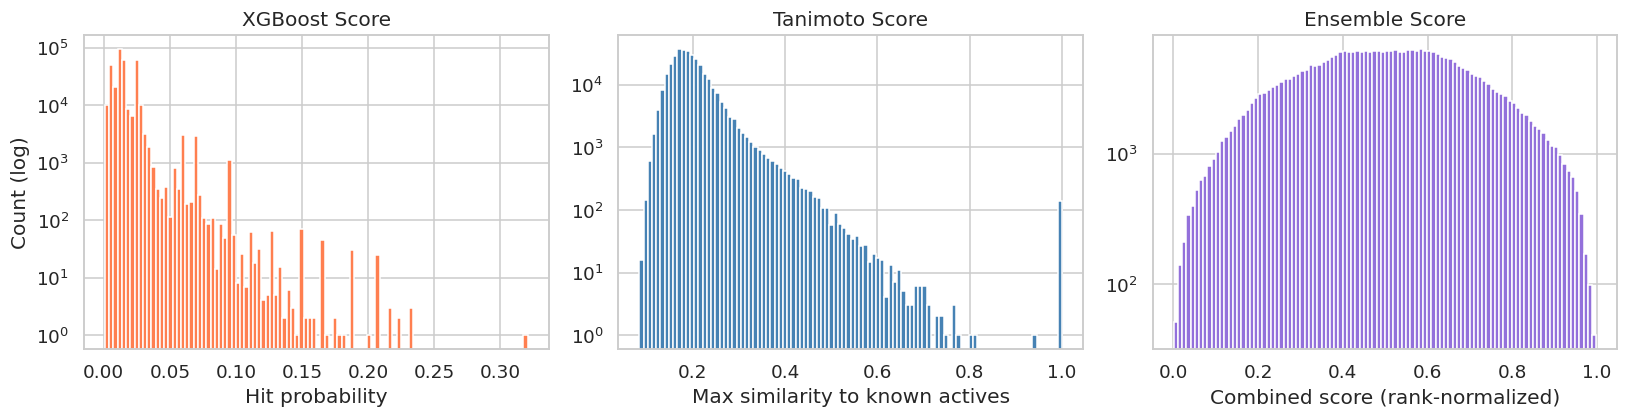

Top 1% (3,392 compounds):
  Mean XGBoost score:          0.0425  (full set: 0.0167)
  Mean Tanimoto score:         0.2923  (full set: 0.1985)
  Overlap with XGBoost-only:   10.9%
  New compounds from Tanimoto: 3,021


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(xgb_scores, bins=100, color='coral', log=True)
axes[0].set_title('XGBoost Score')
axes[0].set_xlabel('Hit probability')
axes[0].set_ylabel('Count (log)')

axes[1].hist(tanimoto_scores, bins=100, color='steelblue', log=True)
axes[1].set_title('Tanimoto Score')
axes[1].set_xlabel('Max similarity to known actives')

axes[2].hist(ensemble_scores, bins=100, color='mediumpurple', log=True)
axes[2].set_title('Ensemble Score')
axes[2].set_xlabel('Combined score (rank-normalized)')

plt.tight_layout()
plt.show()

top1pct = int(len(results) * 0.01)
top_df = results.head(top1pct)
top_xgb_ids = set(results.sort_values('xgb_score', ascending=False).head(top1pct)['RandomID'])
top_ens_ids = set(top_df['RandomID'])
overlap_pct = 100 * len(top_xgb_ids & top_ens_ids) / top1pct

print(f'Top 1% ({top1pct:,} compounds):')
print(f'  Mean XGBoost score:          {top_df["xgb_score"].mean():.4f}  (full set: {xgb_scores.mean():.4f})')
print(f'  Mean Tanimoto score:         {top_df["tanimoto_score"].mean():.4f}  (full set: {tanimoto_scores.mean():.4f})')
print(f'  Overlap with XGBoost-only:   {overlap_pct:.1f}%')
print(f'  New compounds from Tanimoto: {top1pct - len(top_xgb_ids & top_ens_ids):,}')

## 10. Save Ranked Predictions

In [14]:
results.to_csv(OUTPUT_PATH, index=False)
print(f'Saved {len(results):,} ranked predictions to {OUTPUT_PATH}')
results.head()

Saved 339,258 ranked predictions to /content/drive/MyDrive/CS502/outputs/predictions_ensemble.csv


,RandomID,SMILES,xgb_score,tanimoto_score,ensemble_score,rank
0,ID_8999,N#C[C@H]1CC[C@@H](NC(=O)NC2CCCOc3cc(F)ccc32)C1,0.167016,0.447917,0.998088,1
1,ID_116548,O=C(Nc1cccc2ncccc12)C(=O)NC1CC1,0.094459,0.434211,0.996695,2
2,ID_191251,CCOc1c(Cl)cc(CNC(=O)c2ncoc2C2C3CNC2C3)cc1OC,0.115966,0.407407,0.996168,3
3,ID_301084,COCCN1CCC(CNC(=O)c2cc3ccccc3s2)CC1,0.217257,0.395349,0.996086,4
4,ID_18331,COc1cc(NC(=O)NC2CCC(C(=O)O)CC2)ccn1,0.094459,0.436782,0.995572,5
